In [1]:
import itertools
import math
import xml.etree.ElementTree as ET

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import drawsvg as dw

In [2]:
from cycler import cycler

plt.rcParams.update(matplotlib.rcParamsDefault)
plt.rcParams.update({
    "font.family": "FiraGO",  # use serif/main font for text elements
    "svg.fonttype": 'none',
    "font.size": 9,
    "mathtext.fontset": "custom",
    "mathtext.it": "FiraGO:italic",
    "mathtext.rm": "FiraGO",
    "mathtext.fallback": "stixsans",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.prop_cycle": cycler(color=[
        '#084081',
        '#d95f02',
        '#7570b3',
        
        '#e6ab02',
        '#1b9e77',
        '#e7298a',
        
        '#b2182b',
        
        '#1b7837',
        '#8c510a',
        '#666666',
    ]),
    
    "lines.linewidth": 1,
})

In [3]:
def save_svg(drawing, path):
    root = ET.fromstring(d.as_svg())
    root.set('width', f"{d.width}pt")
    root.set('height', f"{d.height}pt")
    with open(path, 'wb') as f:
        ET.ElementTree(root).write(f)

In [4]:
def draw_function(path, dx, dy, func, knots, scale=1.0, h=1e-6):
    func_values = func(knots)
    dfunc_values = np.concatenate([
        (func(knots[:-1] + h) - func_values[:-1])/h,
        (func(knots[[-1]] - h) - func_values[[-1]])/-h,
    ])
    dknots = np.diff(knots)
    
    cpts = []
    for i in range(len(knots) - 1):
        cpts.extend([
            ((i+1/3)*dknots[i], 1/3 * dfunc_values[i] * dknots[i] + func_values[i] - func_values[0]),
            ((i+2/3)*dknots[i], -1/3 * dfunc_values[i+1] * dknots[i] + func_values[i+1] - func_values[0]),
            ((i+1)*dknots[i], func_values[i+1] - func_values[0]),
        ])
    cpts = np.array(cpts)
    
    edge_length = np.sqrt(dx**2 + dy**2)
    edge_angle = np.arctan2(dy, dx)
    cpts[:, 0] *= edge_length/cpts[-1, 0]
    cpts[:, 1] *= scale
    cpts = cpts @ rotation_matrix(edge_angle).T
    draw_cubic_bezier(path, cpts)
    

def draw_cubic_bezier(path, cpts):
    assert len(cpts) % 3 == 0
    cpts = np.asarray(cpts)
    x = np.array([0, 0])
    for x0, x1, xe in zip(cpts[::3], cpts[1::3], cpts[2::3]):
        path.c(*(x0 - x), *(x1 - x), *(xe - x))
        x = xe


def rotation_matrix(theta):
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)],
    ])

In [5]:
INDUCTOR_COIL_ANGLE = np.radians(10)
INDUCTOR_COIL_HEIGHT = 0.81
INDUCTOR_COIL_OVERLAP = 0.29


def draw_inductor(path, dx, dy, turn_width=10, turns=4):
    edge_length = np.sqrt(dx**2 + dy**2)
    edge_angle = np.arctan2(dy, dx)

    coil_points = create_inductor_control_points(turn_width=turn_width, turns=turns)
    coil_length = coil_points[-1, 0]
    pad_length = (edge_length - coil_length)/2

    coil_points = coil_points @ rotation_matrix(edge_angle).T

    path.l(
        pad_length * np.cos(edge_angle),
        pad_length * np.sin(edge_angle),
    )
    draw_cubic_bezier(path, coil_points)
    path.l(
        pad_length * np.cos(edge_angle),
        pad_length * np.sin(edge_angle),
    )


def create_inductor_control_points(turn_width, turns):
    tangent = math.tan(INDUCTOR_COIL_ANGLE)
    height = INDUCTOR_COIL_HEIGHT*turn_width
    overlap = INDUCTOR_COIL_OVERLAP*turn_width
    
    x = np.array([0, 0])
    vertices = []
    for i in itertools.count():
        vertices.extend([
            x + (height*tangent, -height),
            x + (turn_width - height*tangent, -height),
            x + (turn_width, 0),
        ])
        x = vertices[-1]
        if i >= turns: break
        vertices.extend([
            x + (height*tangent, height),
            x + (-overlap - height*tangent, height),
            x + (-overlap, 0),
        ])
        x = vertices[-1]
        
    return np.array(vertices)


def draw_jj(path, dx, dy, size=14, leads=True):
    edge_length = np.sqrt(dx**2 + dy**2)
    edge_angle = np.arctan2(dy, dx)
    
    jj_points = np.array([
        [-size/2, -size/2],
        [size/2, size/2],
        [-size/2, size/2],
        [size/2, -size/2],
    ])
    jj_points = jj_points @ rotation_matrix(edge_angle).T
    
    path.m(
        edge_length/2 * np.cos(edge_angle) + jj_points[0, 0],
        edge_length/2 * np.sin(edge_angle) + jj_points[0, 1],
    )
    path.l(*(jj_points[1] - jj_points[0]))
    path.m(
        -jj_points[1, 0] + jj_points[2, 0],
        -jj_points[1, 1] + jj_points[2, 1],
    )
    path.l(*(jj_points[3] - jj_points[2]))
    
    if leads:
        path.m(
            -jj_points[3, 0] - edge_length/2 * np.cos(edge_angle),
            -jj_points[3, 1] - edge_length/2 * np.sin(edge_angle),
        )
        path.l(
            edge_length * np.cos(edge_angle),
            edge_length * np.sin(edge_angle),
        )
    else:
        path.m(
            -jj_points[3, 0] + edge_length/2 * np.cos(edge_angle),
            -jj_points[3, 1] + edge_length/2 * np.sin(edge_angle),
        )
        

def draw_capacitor(path, dx, dy, plates=True, **kwargs):
    if plates:
        plates_kwargs = {}
        if 'size' in kwargs:
            plates_kwargs['size'] = kwargs['size']
        if 'gap' in kwargs:
            plates_kwargs['gap'] = kwargs['gap']
        draw_capacitor_plates(path, dx, dy, **plates_kwargs)
        path.m(-dx, -dy)
    leads_kwargs = {}
    if 'gap' in kwargs:
        plates_kwargs['gap'] = kwargs['gap']
    if 'side' in kwargs:
        plates_kwargs['side'] = kwargs['side']
    draw_capacitor_leads(path, dx, dy, **leads_kwargs)


def draw_capacitor_plates(path, dx, dy, size=18, gap=5):
    edge_length = np.sqrt(dx**2 + dy**2)
    edge_angle = np.arctan2(dy, dx)
    pad_length = edge_length/2 - gap/2

    path.m(
        pad_length * np.cos(edge_angle) + size/2 * np.sin(edge_angle),
        pad_length * np.sin(edge_angle) - size/2 * np.cos(edge_angle),
    )
    path.l(
        -size * np.sin(edge_angle),
        size * np.cos(edge_angle),
    )
    path.m(
        size * np.sin(edge_angle) + gap * np.cos(edge_angle),
        -size * np.cos(edge_angle) + gap * np.sin(edge_angle),
    )
    path.l(
        -size * np.sin(edge_angle),
        size * np.cos(edge_angle),
    )
    path.m(
        pad_length * np.cos(edge_angle) + size/2 * np.sin(edge_angle),
        pad_length * np.sin(edge_angle) - size/2 * np.cos(edge_angle),
    )


def draw_capacitor_leads(path, dx, dy, gap=5, side='both'):
    edge_length = np.sqrt(dx**2 + dy**2)
    edge_angle = np.arctan2(dy, dx)
    pad_length = edge_length/2 - gap/2
    
    if side in {'start', 'both'}:
        path.l(
            pad_length * np.cos(edge_angle),
            pad_length * np.sin(edge_angle),
        )
        path.m(
            gap * np.cos(edge_angle),
            gap * np.sin(edge_angle),
        )
    else:
        path.m(
            (pad_length + gap) * np.cos(edge_angle),
            (pad_length + gap) * np.sin(edge_angle),
        )
    if side in {'end', 'both'}:
        path.l(
            pad_length * np.cos(edge_angle),
            pad_length * np.sin(edge_angle),
        )
    else:
        path.m(
            pad_length * np.cos(edge_angle),
            pad_length * np.sin(edge_angle),
        )

In [6]:
def build_fluxonium(
    width,
    height,
    anchor='N',
    circuit_stroke_width=1,
    thick_stroke_width=1.5,
    stroke_color='black',
    loop_fill_color='none',
    loop_fill_opacity=1.0,
    inductor_turns=4,
):
    if anchor == 'N':
        lower_left_point = -width/2, height
    else:
        raise ValueError(anchor)
    
    g = dw.Group()
     
    p1 = dw.Path(
        stroke_width=circuit_stroke_width,
        stroke=stroke_color,
        fill='none',
    )
    g.append(p1, z=1)
    
    p1.M(*lower_left_point)
    draw_capacitor_leads(p1, 0, -height, side='end')
    p1.l(width, 0)
    draw_inductor(p1, 0, height, turns=inductor_turns)
    p1.l(-width, 0)
    draw_capacitor_leads(p1, 0, -height, side='start')
    p1.m(width/2, 0)
    p1.l(0, height)

    p2 = dw.Path(
        stroke_width=thick_stroke_width,
        stroke=stroke_color,
        fill='none',
    )
    g.append(p2, z=2)
    
    p2.M(*lower_left_point)
    draw_capacitor_plates(p2, 0, -height)
    p2.m(width/2, 0)
    draw_jj(p2, 0, height, leads=False)
    
    p3 = dw.Path(
        stroke='none',
        fill=loop_fill_color,
        fill_opacity=loop_fill_opacity,
    )
    g.append(p3, z=0)
    p3.M(*lower_left_point)
    p3.m(width, -height)
    draw_inductor(p3, 0, height, turns=inductor_turns)
    p3.l(-width/2, 0)
    p3.l(0, -height)
    p3.Z()
    
    return g

In [7]:
import latex2svg


def build_latex(text, x=0.0, y=0.0, font_size=10, fill='black', text_anchor='start', working_directory=None):
    params = latex2svg.default_params.copy()
    params['preamble'] = r"""\usepackage{xcolor}
\usepackage{unicode-math}
\usepackage{calc}
\setmathfont{Fira Math}[Scale=0.9]
\setmathfontface\mathrm{Fira Math}[Scale=0.9]
\usepackage[sfdefault,scaled=0.9]{FiraSans}
"""
    params['template'] = r"""\documentclass[10pt, preview]{standalone}
{{ preamble }}
\begin{document}
\begin{preview}
\fontsize{{{ fontsize }}}{{{ fontsize }}}\selectfont%
{{ code }}
\end{preview}
\end{document}
"""
    params['fontsize'] = font_size
    params['latex_cmd'] = 'lualatex --interaction=nonstopmode --halt-on-error --output-format=dvi'
    params['dvisvgm_cmd'] =  'dvisvgm --exact-bbox --font-format=woff,autohint'
    
    if fill.startswith("#"):
        params['preamble'] += r"\definecolor{Maincolor}{HTML}{" + fill[1:] + "}"
        color = "Maincolor"
    else:
        color = fill
    
    out = latex2svg.latex2svg(r"\color{" + color + "}" + text, params, working_directory=working_directory)
    
    # latex2svg outputs units in em * 1.00375, we convert it back to points.
    x_offset = 0
    scaling = font_size/1.00375
    y_offset = -scaling*(out['height'] + out['valign'])
    width = scaling*out['width']
    height = scaling*out['height']
    
    if text_anchor == 'middle':
        x_offset = -width/2
    elif text_anchor == 'end':
        x_offset = -width
    
    return dw.Image(
#         x + x_offset,
#         y + y_offset,
        x,
        y,
        width,
        height,
        data=out['svg'].encode('utf8'),
        mime_type='image/svg+xml',
        transform=f"translate({x_offset}, {y_offset})"
    )

In [8]:
COLOR0 = "#084081"
COLOR1 = "#d95f02"
COLOR2 = "#1b7837"
COLOR3 = "#e7298a"

# Circuit diagram

In [9]:
def build_measure_gate(
        size=18,
        label="",
        box_stroke_width=1,
        box_stroke='black',
        box_fill='white',
        dial_stroke_width=1,
        dial_color='black',
        dial_scale=0.7,
        dial_angle=np.pi/4,
):
    g = dw.Group()
    
    p = dw.Path(stroke_width=box_stroke_width, stroke=box_stroke, fill=box_fill)
    g.append(p)
    p.M(-size/2, -size/2)
    p.l(size, 0)
    p.l(0, size)
    p.l(-size, 0)
    p.Z()

    p2 = dw.Path(stroke_width=dial_stroke_width, stroke=dial_color, fill='none')
    g.append(p2)
    p2.M(-dial_scale*size/2, dial_scale*size/2)
    p2.a(
        rx=dial_scale*size/2,
        ry=dial_scale*size/2,
        rot=0,
        large_arc=False,
        sweep=True,
        ex=dial_scale*size,
        ey=0.0,
    )
    p2.M(0, dial_scale*size/2 - dial_stroke_width)
    p2.l(
        1.3*np.cos(dial_angle)*dial_scale*size/2,
        -1.3*np.sin(dial_angle)*dial_scale*size/2,
    )

    g.append(dw.Circle(
        0.0,
        dial_scale*size/2 - dial_stroke_width,
        r=dial_stroke_width,
        fill=dial_color,
        stroke_width=0,
    ))
    
    if label:
        g.append(build_latex(
            text=r"\footnotesize " + label,
            x=size/2 - 2,
            y=-size/2 + 7,
            text_anchor='end',
            fill=dial_color,
        ))
    
    return g

In [10]:
psi_label = build_latex(r"$|\psi\rangle_\mathrm{c}$", 0, 0, fill=COLOR0)
zero_label = build_latex(r"$|\makebox[\widthof{$\psi$}]{$0$}\rangle_\mathrm{t}$", 0, 0, fill=COLOR1)
measure_gate = build_measure_gate(label="Y", box_stroke=COLOR3, dial_color=COLOR3)
cr_label = build_latex(r"\begin{center}Cross\\resonance\end{center}", 0, 0, text_anchor='middle')

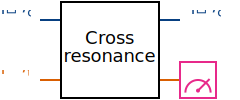

In [11]:
trackc_pos = (20, 10)
trackt_pos = (20, 40)
track_length = 70

circuit_diagram = dw.Group()

circuit_diagram.append(dw.Use(psi_label, x=trackc_pos[0] - 20, y=trackc_pos[1] + 2))
circuit_diagram.append(dw.Use(zero_label, x=trackt_pos[0] - 20, y=trackt_pos[1] + 2))

pc = dw.Path(stroke=COLOR0, stroke_width=1)
pc.M(*trackc_pos)
pc.l(track_length, 0)
circuit_diagram.append(pc)
pt = dw.Path(stroke=COLOR1, stroke_width=1)
pt.M(*trackt_pos)
pt.l(track_length, 0)
circuit_diagram.append(pt)

p2 = dw.Path(stroke='black', stroke_width=1, fill='white')
p2.M(trackc_pos[0] + 0.15*track_length, trackc_pos[1] - 9)
p2.l(0.7*track_length, 0)
p2.l(0, trackt_pos[1] - trackc_pos[1] + 18)
p2.l(-0.7*track_length, 0)
p2.Z()
circuit_diagram.append(p2)

circuit_diagram.append(dw.Use(psi_label, x=trackt_pos[0] + track_length + 5, y=trackc_pos[1] + 2))
circuit_diagram.append(dw.Use(measure_gate, x=trackt_pos[0] + track_length + 9, y=trackt_pos[1]))

# circuit_diagram.append(
#     dw.Use(
#         cr_label,
#         trackc_pos[0] + track_length/2,
#         (trackc_pos[1] + trackt_pos[1])/2 + 7,
#     )
# )


circuit_diagram.append(
    dw.Text(
        "Cross\nresonance",
        9,
        font_family="FiraGO",
        font_weight=400,
        dominant_baseline='auto',
        text_anchor='middle',
        x=trackc_pos[0] + track_length/2,
        y=(trackc_pos[1] + trackt_pos[1])/2 - 3,
    )
)

d = dw.Drawing(120, 50, origin=(0, 0))
d.set_pixel_scale(2)  # Set number of pixels per geometry unit
d.append(circuit_diagram)
d

0.2710027100271003

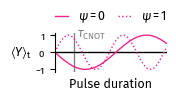

In [53]:
plt.figure(figsize=(40/25.4, 20/25.4))#, facecolor='red')

xx = np.linspace(0, 1, 1000)
f1 = 1.234 / 1.35
f2 = 2.456 / 1.2
yy1 = np.sin(-2*np.pi*f1*xx)
yy2 = np.sin(2*np.pi*f2*xx)

plt.axhline(0, c='black')
plt.plot(xx, yy1, c=COLOR3, label=r"$\psi=0$")
plt.plot(xx, yy2, c=COLOR3, ls=':', label=r"$\psi=1$")

plt.xlabel(r"Pulse duration")
plt.ylabel(r"$\langle Y\rangle_\mathrm{t}$", rotation=0, va="center", labelpad=10)
plt.yticks([-1, 0, 1], ["$-1$", "$0$", r"$1$"])
plt.xticks([])
plt.xlim(min(xx), max(xx))
plt.ylim(-1.15, 1.15)
plt.gca().spines[['right', 'top', 'bottom']].set_visible(False)
plt.gca().patch.set_alpha(0)
plt.subplots_adjust(top=0.72, bottom=0.22, left=0.28, right=0.99)
plt.legend(
    ncol=2,
    bbox_to_anchor=(1, 1.2),
    loc='lower right',
    frameon=False,
    columnspacing=1,
    borderaxespad=0,
    borderpad=0,
    handlelength=1,
)

plt.axvline(0.5/(f1+f2), color='gray', zorder=-10)
plt.annotate(
    r"$\tau_{\mathrm{CNOT}}$",
    (0.5/(f1+f2), 1),
    xytext=(2.5, 0),
    textcoords='offset points',
    color='gray',
    va='center',
    ha='left',
)

plt.savefig("measurement_trace.svg", transparent=True)
plt.show()
# turn off top and bottom frame and right frame

In [42]:
FLUXONIUM_WIDTH = 65
FLUXONIUM_HEIGHT = 60
CIRCUIT_STROKE_WIDTH = 1

def build_my_fluxonium(color):
    fluxonium = build_fluxonium(
        width=FLUXONIUM_WIDTH,
        height=FLUXONIUM_HEIGHT,
        anchor='N',
        circuit_stroke_width=CIRCUIT_STROKE_WIDTH,
        stroke_color=color,
        loop_fill_color=color,
        loop_fill_opacity=0.2,
    )
    half_flux_label = build_external_flux_label(r"$\Phi_0/2$", color=color)
    fluxonium.append(
        dw.Use(
            half_flux_label,
            0.25 * FLUXONIUM_WIDTH,
            0.68 * FLUXONIUM_HEIGHT,
        )
    )
    return fluxonium


def build_external_flux_label(text, color='black'):
    g = dw.Group()
    g.append(dw.Circle(
        0.0, 0.0,
        2.9,
        stroke=color,
        stroke_width=0.5,
        fill='none',
    ))
    g.append(dw.Circle(
        0.0, 0.0,
        1,
        fill=color,
    ))
    g.append(
        build_latex(
            text,
            0.0, 14.0,
            font_size=10,
            text_anchor='middle',
            fill=color,
        )
    )
    return g


def build_energy_labels(subscript, color):
    g = dw.Group()
    g.append(
        build_latex(
            r"$E_{C,\mathrm{" + subscript + "}}$",
            -FLUXONIUM_WIDTH/2,
            0.0,
            text_anchor='middle',
            fill=color,
        )
    )
    g.append(
        build_latex(
            r"$E_{J,\mathrm{" + subscript + "}}$",
            0.0,
            0.0,
            text_anchor='middle',
            fill=color,
        )
    )
    g.append(
        build_latex(
            r"$E_{L,\mathrm{" + subscript + "}}$",
            FLUXONIUM_WIDTH/2,
            0.0,
            text_anchor='middle',
            fill=color,
        )
    )
    return g

fx0 = build_my_fluxonium(COLOR0)
fx1 = build_my_fluxonium(COLOR1)

fx0_energy_labels = build_energy_labels("c", COLOR0)
fx1_energy_labels = build_energy_labels("t", COLOR1)

coupling_label = build_latex(
    "$J\hat n_\mathrm{c} \hat n_\mathrm{t}$",
    0.0,
    0.0,
    text_anchor='middle',
    fill=COLOR2
)

drive_signal_label = build_latex(
    "$\Omega\sin\omega_\mathrm{d}t$",
    0.0,
    0.0,
    text_anchor='middle',
    fill=COLOR1
)

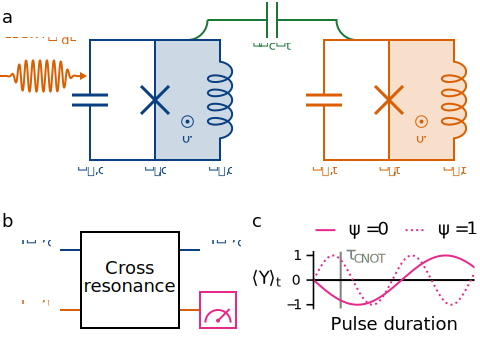

In [50]:
d = dw.Drawing(240, 170, origin=(0, 0))
d.set_pixel_scale(2)  # Set number of pixels per geometry unit
d.append_css(f"""@page {{
  margin: 0;
  padding: 0;
  size: {d.width}pt {d.height}pt;
}}""")

# d.append_css(f"""@page {{
#   margin: 0;
#   padding: 0;
#   size: 85mm {d.height}pt;
# }}""")

# for ff in font_faces:
#     d.append_css(ff)

drive_signal_width = 40
drive_signal_margin = 5
fx0_position = np.array([
    drive_signal_width + drive_signal_margin + FLUXONIUM_WIDTH/2,
    20,
])
fx1_position = fx0_position + np.array([1.8*FLUXONIUM_WIDTH, 0.0])

x0 = fx0_position + (FLUXONIUM_WIDTH/4, 0)
x1 = fx1_position - (FLUXONIUM_WIDTH/4, 0)
coupling_slant = np.array([10, -10])

coupling_path = dw.Path(
    stroke_width=CIRCUIT_STROKE_WIDTH,
    stroke=COLOR2,
    fill='none',
)
coupling_path.M(*x0)
# coupling_path.l(*coupling_slant)
coupling_path.a(
    rx=coupling_slant[0],
    ry=coupling_slant[1],
    rot=0,
    large_arc=False,
    sweep=1,
    ex=coupling_slant[0],
    ey=coupling_slant[1],
)
draw_capacitor(
    coupling_path,
    x1[0] - x0[0] - 2*coupling_slant[0],
    x1[1] - x0[1],
)
# coupling_path.l(coupling_slant[0], -coupling_slant[1])
coupling_path.a(
    rx=coupling_slant[0],
    ry=coupling_slant[1],
    rot=0,
    large_arc=False,
    sweep=1,
    ex=coupling_slant[0],
    ey=-coupling_slant[1],
)
d.append(coupling_path)

coupling_label.args['x'] = (x0[0] + x1[0])/2
coupling_label.args['y'] = x0[1] + 9
d.append(coupling_label)

fx0_energy_labels.args['transform'] = f"""translate(
{fx0_position[0]},
{fx0_position[1] + FLUXONIUM_HEIGHT + 10})"""
fx1_energy_labels.args['transform'] = f"""translate(
{fx1_position[0]},
{fx1_position[1] + FLUXONIUM_HEIGHT + 10})"""
d.append(fx0_energy_labels)
d.append(fx1_energy_labels)

d.append(dw.Use(fx0, *fx0_position))
d.append(dw.Use(fx1, *fx1_position))

def signal_function(t):
    plateau = 0.3
    rise = 0.2
    envelope = 0.5 * (np.tanh(4*(t + plateau)/rise) - np.tanh(4*(t - plateau)/rise))
    carrier = np.sin(2*np.pi*12*t)
    return envelope * carrier


drive_path_position = np.array([
    fx0_position[0] - FLUXONIUM_WIDTH/2 - drive_signal_width - drive_signal_margin,
    fx0_position[1] + 0.3*FLUXONIUM_HEIGHT,
])
drive_path = dw.Path(
    stroke_width=CIRCUIT_STROKE_WIDTH,
    stroke=COLOR1,
    fill='none',
)
drive_path.M(*drive_path_position)
draw_function(
    drive_path,
    drive_signal_width,
    -0,
    signal_function,
    knots=np.linspace(-0.5, 0.5, 12 * 2, endpoint=False),
    scale=10,
)
d.append(drive_path)

drive_path_arrow_size = 2
drive_path_arrow = dw.Path(
    stroke='none',
    fill=COLOR1,
)
drive_path_arrow.M(
    drive_path_position[0] + drive_signal_width,
    drive_path_position[1] - drive_path_arrow_size,
)
drive_path_arrow.l(0, 2*drive_path_arrow_size)
drive_path_arrow.l(drive_path_arrow_size/np.tan(np.pi/6), -drive_path_arrow_size)
drive_path_arrow.Z()
d.append(drive_path_arrow)

drive_signal_label.args['x'] = drive_path_position[0] + drive_signal_width/2
drive_signal_label.args['y'] = drive_path_position[1] - 12
d.append(drive_signal_label)

d.append(dw.Use(
    circuit_diagram,
    10.0,
    fx0_position[1] + FLUXONIUM_HEIGHT + 35,
))

d.append(
    dw.Image(
        125,
        fx0_position[1] + FLUXONIUM_HEIGHT + 30,
        40/25.4*72,
        20/25.4*72,
        "measurement_trace.svg",
        embed=True,
    ),
)

d.append(
    dw.Text(
        "a",
        9,
        x=1,
        y=3,
        font_family="FiraGO",
        font_weight=500,
        dominant_baseline='hanging',
        text_anchor='start',
    )
)

d.append(
    dw.Text(
        "b",
        9,
        font_family="FiraGO",
        font_weight=500,
        dominant_baseline='hanging',
        text_anchor='start',
        x=1,
        y=fx0_position[1] + FLUXONIUM_HEIGHT + 25
    )
)

d.append(
    dw.Text(
        "c",
        9,
        font_family="FiraGO",
        font_weight=500,
        dominant_baseline='hanging',
        text_anchor='start',
        x=126,
        y=fx0_position[1] + FLUXONIUM_HEIGHT + 25
    )
)

d

In [51]:
# Text can become wonky for some reason using headless mode.
save_svg(d, "cr_schematic.svg")
# !chromium --headless --disable-gpu --print-to-pdf-no-header --print-to-pdf=example.pdf example.svg

In [ ]:
# Use Chrome to print svg to pdf.